<a href="https://colab.research.google.com/github/ParusSlava/DTA_2026/blob/main/homework/19_06_26_nazar_practice_stat_tests_HARDER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Статистичні тести: поглиблений практикум

**Рівень:** середній+ · фокус на **інтерпретації** · бібліотека `scipy.stats`

---

Цей практикум складніший за попередній. Тут менше «механічного» застосування тестів і більше **роздумів**: ви будете обирати тести самостійно, помічати пастки і — найголовніше — **пояснювати, що результат означає для бізнесу**.

### Що нового порівняно з минулим практикумом
- 🧠 Більшість завдань вимагають, щоб ви **самі обрали тест** і обґрунтували вибір.
- 🪤 Тут є **пастки**: випадки, де p < 0.05, але результат практично не важливий; де дані спотворені викидами; де результат «на межі».
- 💬 На кожне завдання — **розгорнута інтерпретація**. Саме це відрізняє аналітика від калькулятора.

### Як працювати
1. До кожного завдання є **підказки** — користуйтесь ними, але спершу подумайте самі.
2. Інтерпретації пишіть так, ніби пояснюєте керівнику **без** статистичної освіти.
3. Не зупиняйтесь на «p < 0.05, значущо» — завжди питайте: *наскільки великий ефект? чи це важливо на практиці? чи можна довіряти даним?*

> ⚠️ Головна теза практикуму: **статистична значущість ≠ практична важливість.** Тримайте це в голові протягом усієї роботи.

---

## Підготовка

Працюємо з даними SaaS-продукту (онлайн-сервіс за підпискою). Запустіть клітинку нижче.

**`saas_users.csv`** — 1200 користувачів:

| Стовпець | Опис | Тип |
|---|---|---|
| `user_id` | ID користувача | — |
| `plan` | Тариф (Free / Pro / Business) | категоріальний |
| `region` | Регіон (Europe / Americas / Asia) | категоріальний |
| `signup_source` | Джерело реєстрації (Search / Referral / Ads / Social) | категоріальний |
| `support_tickets` | Кількість звернень у підтримку | числовий |
| `weekly_sessions` | Сеансів на тиждень | числовий |
| `feature_adopted` | Чи почав користуватись новою функцією (Так/Ні) | категоріальний |
| `nps_before` | Оцінка лояльності NPS ДО оновлення (0-10) | числовий |
| `nps_after` | NPS ПІСЛЯ оновлення (0-10) | числовий |

**`onboarding_ab.csv`** — A/B-тест нового онбордингу (100 000 користувачів!):

| Стовпець | Опис |
|---|---|
| `user_id` | ID |
| `variant` | Control (старий онбординг) або Treatment (новий) |
| `signed_up` | Чи завершив реєстрацію (1/0) |


In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

users = pd.read_csv("saas_users.csv")
ab = pd.read_csv("onboarding_ab.csv")

print("Користувачі:", users.shape)
print("A/B онбординг:", ab.shape)
users.head()

Користувачі: (1200, 9)
A/B онбординг: (100000, 3)


,user_id,plan,region,signup_source,support_tickets,weekly_sessions,feature_adopted,nps_before,nps_after
0,10001,Free,Americas,Social,2,11,Так,5,3
1,10002,Pro,Asia,Search,12,16,Ні,6,3
2,10003,Free,Asia,Social,6,11,Ні,5,5
3,10004,Business,Americas,Referral,4,27,Ні,7,7
4,10005,Pro,Asia,Referral,1,8,Ні,4,6


---
# Розділ 1. Спочатку — подивись на дані уважно

## 🟦 Чому це важливо
Перш ніж застосовувати тести, аналітик завжди вивчає дані. Тести роблять припущення (наприклад, t-тест найкраще працює, коли дані приблизно симетричні). Якщо дані сильно спотворені викидами — середнє може вводити в оману, і висновок тесту теж.

#### ✏️ Завдання 1 (код)

Виведіть описову статистику (`.describe()`) для числових стовпців. Окремо порівняйте **середнє** і **медіану** стовпця `support_tickets`.

> 💡 **Підказка:** Для медіани: `users['support_tickets'].median()`. Зверніть увагу, чи сильно середнє відрізняється від медіани.

In [18]:
# Завдання 1:
print(users.describe())
print(users['support_tickets'].median())

            user_id  support_tickets  weekly_sessions   nps_before  \
count   1200.000000      1200.000000      1200.000000  1200.000000   
mean   10600.500000         2.105000        11.500833     6.930000   
std      346.554469         2.606333         6.395109     1.916114   
min    10001.000000         0.000000         1.000000     1.000000   
25%    10300.750000         0.000000         7.000000     6.000000   
50%    10600.500000         1.000000        11.000000     7.000000   
75%    10900.250000         3.000000        16.000000     8.000000   
max    11200.000000        20.000000        38.000000    10.000000   

         nps_after  
count  1200.000000  
mean      7.149167  
std       2.200216  
min       0.000000  
25%       6.000000  
50%       7.000000  
75%       9.000000  
max      10.000000  
1.0


#### 💬 Інтерпретація 1

Порівняйте середнє і медіану `support_tickets`. Що це говорить про форму розподілу (чи є викиди — користувачі з дуже великою кількістю звернень)? Чому для такого стовпця варто бути обережним із t-тестом?

> 🧭 **Орієнтир для відповіді:** Якщо середнє помітно більше за медіану — розподіл «витягнутий» вправо (є кілька користувачів з дуже багатьма зверненнями). Подумайте, як викиди впливають на середнє.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Середнє значення support_tickets дорівнює 2.105, тоді як медіана — лише 1.0. Це означає, що більшість користувачів звертається до підтримки рідко (0–1 раз), але є невелика група людей із дуже великою кількістю звернень (максимум — 20), яка «підтягує» середнє вгору.    

#### ✏️ Завдання 2 (код)

Побудуйте гістограму `support_tickets`, щоб побачити розподіл на власні очі.

> 💡 **Підказка:** `users['support_tickets'].plot(kind='hist', bins=20)` і потім `plt.show()`.

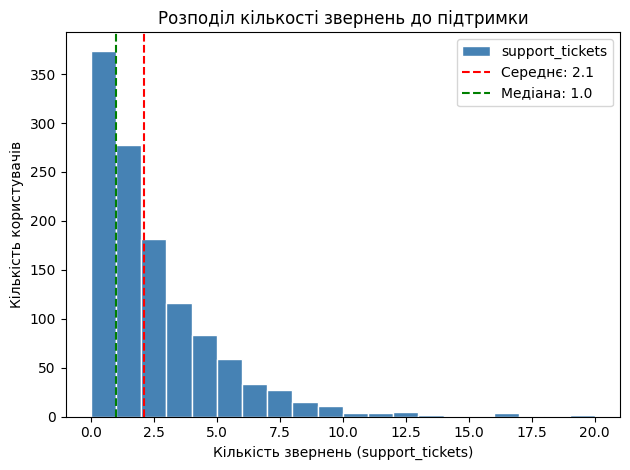

In [19]:
# Завдання 2:
users['support_tickets'].plot(kind='hist', bins=20, color='steelblue', edgecolor='white')
plt.title('Розподіл кількості звернень до підтримки')
plt.xlabel('Кількість звернень (support_tickets)')
plt.ylabel('Кількість користувачів')
plt.axvline(users['support_tickets'].mean(), color='red', linestyle='--', label=f"Середнє: {users['support_tickets'].mean():.1f}")
plt.axvline(users['support_tickets'].median(), color='green', linestyle='--', label=f"Медіана: {users['support_tickets'].median():.1f}")
plt.legend()
plt.tight_layout()
plt.show()

#### 💬 Інтерпретація 2

Що видно на гістограмі? Підтверджує вона ваш висновок про викиди з попереднього завдання?

> 🧭 **Орієнтир для відповіді:** Опишіть форму: чи більшість значень малі, а «хвіст» тягнеться до великих? Це типовий скошений (skewed) розподіл.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Розподіл має виражену праву асиметрію:    

Переважна більшість користувачів (майже 370 осіб) мають 0 звернень, ще близько 275 — лише 1 звернення. Тобто більш ніж половина бази взагалі майже не контактує з підтримкою.    
«Хвіст» розподілу повільно тягнеться праворуч аж до значення 20 звернень — це і є ті самі викиди, про які йшлося раніше.    
Видно, що зелена лінія (медіана = 1.0) стоїть лівіше від червоної (середнє = 2.1) — саме тому, що кілька «важких» користувачів із правого хвоста підтягують середнє вгору.    



---
# Розділ 2. Порівняння кількох груп — обери тест сам

## 🟦 Нагадування
Коли треба порівняти числову величину між **3+ групами**, згадайте, який тест підходить. Не забувайте: він каже лише, що різниця *десь є*, але не каже, *між якими саме* групами.

#### ✏️ Завдання 3 (код)

Користувачі різних тарифів (`plan`) можуть по-різному користуватись продуктом. Перевірте, чи відрізняється середня кількість сеансів на тиждень (`weekly_sessions`) між тарифами Free / Pro / Business. Спершу виведіть середні по групах, потім проведіть відповідний тест.

> 💡 **Підказка:** Три групи + числова змінна → ANOVA (`stats.f_oneway`). Зберіть групи у список: `[users[users.plan==p].weekly_sessions for p in users.plan.unique()]`.

In [21]:
# Завдання 3:
print("Середні weekly_sessions по тарифах:")
print(users.groupby('plan')['weekly_sessions'].mean().round(2))
print()

groups = [users[users['plan'] == p]['weekly_sessions'] for p in users['plan'].unique()]

f_stat, p_value = stats.f_oneway(*groups)
print(f"F-статистика: {f_stat:.4f}")
print(f"p-value:      {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ Різниця між тарифами статистично значуща (p < 0.05)")
else:
    print("\n❌ Статистично значущої різниці не виявлено (p ≥ 0.05)")


Середні weekly_sessions по тарифах:
plan
Business    19.59
Free         7.93
Pro         13.30
Name: weekly_sessions, dtype: float64

F-статистика: 415.1936
p-value:      0.0000

✅ Різниця між тарифами статистично значуща (p < 0.05)


#### 💬 Інтерпретація 3

Чи відрізняються тарифи за активністю? Який тариф найактивніший? І ключове питання: чому за результатом ANOVA ви НЕ можете одразу стверджувати, що, наприклад, Pro значущо активніший за Free? Що для цього треба було б зробити додатково?

> 🧭 **Орієнтир для відповіді:** ANOVA виявляє різницю «хоча б десь». Для конкретних пар потрібні post-hoc тести (напр. Тьюкі) або попарні порівняння з поправкою на множинність.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Чітка градація: чим вищий тариф — тим активніше користувач залучений у продукт. Це цілком логічно: платні клієнти мають більше причин і можливостей користуватись сервісом.    
 - F-статистика = 415.19,

 - p-value ≈ 0.0000    

`F-статистика` дуже велика — це означає, що варіація між групами (різниця між тарифами) набагато перевищує варіацію всередині груп (різниця між окремими користувачами в межах одного тарифу). p-value практично нульовий — імовірність отримати таку різницю випадково є нескінченно малою.    
**Важливе застереження:** ANOVA каже лише те, що десь є різниця — але не уточнює, між якими саме парами. Для цього потрібен post-hoc тест. Втім, з огляду на те, що всі три середні добре розрізняються (7.9 → 13.3 → 19.6), найімовірніше різниця є між кожною парою тарифів.

**Висновок:** активність у продукті зростає разом із тарифом. Це може означати як те, що активніші користувачі обирають вищі тарифи, так і те, що вищий тариф дає більше функцій і стимулює використання — для розрізнення цих причин потрібне окреме дослідження.

#### ✏️ Завдання 4 (код)

Тепер перевірте, чи відрізняється `weekly_sessions` між регіонами (`region`).

> 💡 **Підказка:** Той самий тест, що й вище, але групуєте за `region`.

In [22]:
# Завдання 4:
print("Середні weekly_sessions по регіонам:")
print(users.groupby('region')['weekly_sessions'].mean().round(2))
print()

groups = [users[users['region'] == p]['weekly_sessions'] for p in users['region'].unique()]

f_stat, p_value = stats.f_oneway(*groups)
print(f"F-статистика: {f_stat:.4f}")
print(f"p-value:      {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ Різниця між регіонами статистично значуща (p < 0.05)")
else:
    print("\n❌ Статистично значущої різниці не виявлено (p ≥ 0.05)")


Середні weekly_sessions по регіонам:
region
Americas    10.78
Asia        11.52
Europe      12.28
Name: weekly_sessions, dtype: float64

F-статистика: 5.5455
p-value:      0.0040

✅ Різниця між регіонами статистично значуща (p < 0.05)


#### 💬 Інтерпретація 4

Порівняйте цей результат із попереднім (тарифи). В одному випадку різниця значуща, в іншому — ні (або слабша). Що це означає для продукту: який фактор (тариф чи регіон) сильніше пов'язаний з активністю користувача?

> 🧭 **Орієнтир для відповіді:** Зверніть увагу не лише на сам факт значущості, а й на те, наскільки далекі середні між групами одне від одного.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Обидва тести показали статистично значущий результат (p < 0.05), але сила ефекту принципово різна.    

Різниця між тарифами — майже 12 сеансів на тиждень, тоді як між регіонами — лише 1.5 сеансу. І це підтверджується F-статистикою: 415.19 проти 5.55 — тобто тариф пояснює активність у 75 разів потужніше, ніж регіон.    
Що це означає для продукту:    
Тариф є ключовим предиктором активності — саме він визначає, наскільки інтенсивно людина користується продуктом. Регіон теж має статистичний вплив, але він настільки малий, що з практичної точки зору майже не важливий: користувач з Європи в середньому робить лише на 1–2 сеанси більше, ніж з Америки — це не та різниця, під яку варто будувати окрему стратегію.    

**Висновок:** якщо команда хоче підвищити залученість користувачів — головний важіль це апгрейд тарифу, а не регіональна адаптація продукту. Зусилля на конвертацію Free → Pro → Business дадуть набагато більший ефект, ніж регіональна локалізація функцій.    

---
# Розділ 3. До і після — і розмір ефекту

## 🟦 Новий акцент: розмір ефекту
Тут ви зустрінете важливу пастку. Тест може показати «значущо» (p < 0.05), але **величина зміни** може бути крихітною. Аналітик завжди дивиться на обидві речі: і p-значення, і **наскільки великий** ефект.

#### ✏️ Завдання 5 (код)

Компанія оновила онбординг і виміряла NPS (лояльність) тих самих користувачів до (`nps_before`) і після (`nps_after`). Проведіть відповідний тест. Додатково порахуйте **середню зміну** NPS (різницю after − before).

> 💡 **Підказка:** Ті самі користувачі двічі → парний t-тест (`stats.ttest_rel`). Середня зміна: `(users['nps_after'] - users['nps_before']).mean()`.

In [7]:
# Завдання 5:


#### 💬 Інтерпретація 5

Тут — важлива пастка. Подивіться на p-значення І на розмір зміни. Чи зміна статистично значуща? А наскільки вона велика в балах NPS? Чи варто компанії святкувати «значуще покращення», якщо середній NPS зріс лише на ~0.2 бала з 10? Сформулюйте збалансований висновок.

> 🧭 **Орієнтир для відповіді:** Розрізняйте «статистично значущо» (різниця не випадкова) і «практично важливо» (різниця достатньо велика, щоб мати сенс для бізнесу). Тут перше — так, а друге — під питанням.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*...*

---
# Розділ 4. 🪤 Велика пастка: A/B-тест на 100 000 користувачів

## 🟦 Контекст
Це найважливіший розділ практикуму. Компанія протестувала новий онбординг (Treatment) проти старого (Control) на **100 тисячах** користувачів. Через величезний обсяг даних тут виявляється класична пастка статистики.

#### ✏️ Завдання 6 (код)

Порахуйте конверсію реєстрації (`signed_up`) для кожного варіанта (Control і Treatment). На скільки **відсоткових пунктів** відрізняється конверсія?

> 💡 **Підказка:** `ab.groupby('variant')['signed_up'].mean()`. Відсоткові пункти = різниця часток × 100.

In [8]:
# Завдання 6:


#### 💬 Інтерпретація 6

Яка різниця конверсій між варіантами у відсоткових пунктах? На перший погляд — це багато чи мало?

> 🧭 **Орієнтир для відповіді:** Просто опишіть числа поки що. Наприклад, «різниця склала менше 1 відсоткового пункту».

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*...*

#### ✏️ Завдання 7 (код)

Проведіть статистичний тест, щоб перевірити, чи різниця конверсій значуща (дані категоріальні: варіант × signed_up).

> 💡 **Підказка:** Категоріальні дані → хі-квадрат. `pd.crosstab(ab.variant, ab.signed_up)`, потім `stats.chi2_contingency`.

In [9]:
# Завдання 7:


#### 💬 Інтерпретація 7

🪤 ОСЬ ПАСТКА. Тест майже напевно покаже, що різниця **статистично значуща** (p < 0.05). Але різниця в конверсії — менше 1 відсоткового пункту. Поясніть цей парадокс: як крихітна різниця може бути «значущою»? Яку роль тут відіграє величезний обсяг вибірки (100 тисяч)?

> 🧭 **Орієнтир для відповіді:** При дуже великих вибірках навіть мікроскопічні різниці стають статистично значущими, бо тест дуже «чутливий». Значущість говорить «різниця не нульова», але нічого не каже про те, чи вона ВЕЛИКА.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*...*

#### 💬 Інтерпретація 8

Фінальне рішення аналітика. Уявіть, що впровадження нового онбордингу коштує дорого (треба переписати код, навчити команду). Чи варто впроваджувати Treatment заради приросту в ~0.9 відсоткового пункту? Сформулюйте аргументовану рекомендацію, яка враховує і статистику, і практичний бік.

> 🧭 **Орієнтир для відповіді:** Тут немає єдиної правильної відповіді — важлива логіка. Згадайте: статистична значущість ≠ практична важливість. Варто зважити розмір ефекту проти вартості впровадження та обсягу бізнесу.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*...*

---
# Розділ 5. Зв'язок категорій — і результат «на межі»

## 🟦 Що тренуємо
Тут — звичайний хі-квадрат, але один із результатів буде **близьким до межі 0.05**. Це привід поговорити про те, що поріг 0.05 — умовність, а не магія.

#### ✏️ Завдання 8 (код)

Перевірте, чи пов'язаний тариф (`plan`) із тим, чи почав користувач застосовувати нову функцію (`feature_adopted`). Побудуйте таблицю спряженості і проведіть тест.

> 💡 **Підказка:** Дві категоріальні змінні → хі-квадрат. Не забудьте спершу `pd.crosstab(users.plan, users.feature_adopted)`.

In [10]:
# Завдання 8:


#### 💬 Інтерпретація 9

Чи пов'язаний тариф із прийняттям функції? Подивіться на таблицю спряженості: користувачі якого тарифу найчастіше приймають функцію? Що це означає для продуктової стратегії?

> 🧭 **Орієнтир для відповіді:** Порахуйте частку «Так» у кожному тарифі (наприклад, для Business: Так / (Так+Ні)). Порівняйте частки між тарифами.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*...*

#### ✏️ Завдання 9 (код)

Тепер перевірте, чи пов'язане джерело реєстрації (`signup_source`) із прийняттям функції (`feature_adopted`).

> 💡 **Підказка:** Знову хі-квадрат, але для `signup_source` × `feature_adopted`.

In [11]:
# Завдання 9:


#### 💬 Інтерпретація 10

Цей результат, імовірно, буде «на межі» (p близько 0.05–0.07). Як трактувати такий пограничний випадок? Чи коректно сказати «майже значущо» і впевнено заявити про зв'язок? Що б ви порадили зробити, перш ніж робити висновок?

> 🧭 **Орієнтир для відповіді:** Поріг 0.05 — умовність. Результат трохи вище 0.05 означає «недостатньо доказів за обраного порогу». Не варто оголошувати зв'язок; розумно зібрати більше даних або поставитись обережно.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*...*

---
# Розділ 6. Кореляція та хибні висновки про причинність

## 🟦 Що тренуємо
Числові зв'язки + критичне мислення про причинність.

#### ✏️ Завдання 10 (код)

Перевірте, чи пов'язана кількість звернень у підтримку (`support_tickets`) із кількістю сеансів на тиждень (`weekly_sessions`). Порахуйте кореляцію Пірсона.

> 💡 **Підказка:** `stats.pearsonr(users['support_tickets'], users['weekly_sessions'])`. Дивіться і на r, і на p.

In [12]:
# Завдання 10:


#### 💬 Інтерпретація 11

Опишіть зв'язок (сила, напрямок, значущість). Уявіть, що колега каже: «Більше звернень у підтримку — значить, треба зменшити кількість сеансів, бо сеанси викликають проблеми». Що не так із цим міркуванням?

> 🧭 **Орієнтир для відповіді:** По-перше, оцініть, чи зв'язок узагалі є (подивіться на r і p). По-друге — навіть за наявності зв'язку кореляція не доводить причинність; напрямок «сеанси → звернення» — лише припущення.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*...*

---
# Розділ 7. 🧩 Відкритий кейс: повний аналіз

## 🟦 Завдання-кейс
Тут немає підказок про конкретний тест — ви аналітик, і вам треба самостійно пройти весь шлях. Це імітація реального робочого завдання.

**Ситуація:** керівництво хоче зрозуміти, що відрізняє користувачів тарифу **Business** (найдорожчий) від інших. Ваша мета — знайти хоча б два статистично обґрунтовані інсайти про користувачів Business.

#### ✏️ Завдання 11 (код)

Крок 1. Створіть новий стовпець `is_business`, який дорівнює 'Так', якщо тариф Business, інакше 'Ні'. Це поділить користувачів на дві групи для порівнянь.

> 💡 **Підказка:** `users['is_business'] = (users['plan'] == 'Business').map({True:'Так', False:'Ні'})` або через `np.where`.

In [13]:
# Завдання 11:


#### ✏️ Завдання 12 (код)

Крок 2. Сформулюйте і перевірте ПЕРШУ гіпотезу: чи відрізняються Business-користувачі за `weekly_sessions` від решти? Оберіть і проведіть доречний тест.

> 💡 **Підказка:** Дві групи (Business vs решта) + числова змінна → двовибірковий t-тест (`stats.ttest_ind`).

In [14]:
# Завдання 12:


#### 💬 Інтерпретація 12

Сформулюйте перший інсайт: чим Business-користувачі відрізняються за активністю? Наведіть і числа (середні), і висновок тесту.

> 🧭 **Орієнтир для відповіді:** Порівняйте середні двох груп і вкажіть, чи різниця значуща. Перекладіть це мовою бізнесу.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*...*

#### ✏️ Завдання 13 (код)

Крок 3. Сформулюйте і перевірте ДРУГУ гіпотезу: чи пов'язаний статус Business із прийняттям функції (`feature_adopted`)? Оберіть доречний тест.

> 💡 **Підказка:** Дві категоріальні змінні (`is_business` × `feature_adopted`) → хі-квадрат.

In [15]:
# Завдання 13:


#### 💬 Інтерпретація 13

Сформулюйте другий інсайт. Чи частіше Business-користувачі приймають нову функцію?

> 🧭 **Орієнтир для відповіді:** Подивіться на частки «Так» у групах Business та не-Business у таблиці спряженості.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*...*

#### 💬 Інтерпретація 14

Підсумок кейсу. Зберіть ваші знахідки в короткий звіт (3-4 речення) для керівництва: який «портрет» Business-користувача вимальовується з даних? Які з висновків статистично надійні, а де варто бути обережним?

> 🧭 **Орієнтир для відповіді:** Хороший звіт поєднує кілька знахідок, чесно зазначає рівень упевненості й уникає тверджень про причинність там, де є лише кореляція.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*...*

---
# 🎉 Готово!

Ви пройшли поглиблений практикум, де головним було не «порахувати p-значення», а **зрозуміти й пояснити** результат.

## Що ви потренували
- ✅ Самостійний вибір тесту під задачу
- ✅ Розрізнення **статистичної значущості** та **практичної важливості** (пастка з 100 000 користувачів)
- ✅ Увагу до **розміру ефекту**, а не лише до p < 0.05
- ✅ Обережність із **скошеними даними** та викидами
- ✅ Трактування **пограничних** результатів (p ≈ 0.05)
- ✅ Критичне мислення про **причинність** (кореляція ≠ причина)
- ✅ Складання звіту для бізнесу

## Головна думка
> P-значення — це початок розмови, а не її кінець. Хороший аналітик завжди питає далі: *наскільки великий ефект? чи це важливо? чи можна довіряти даним? чи це причина — чи лише зв'язок?*

Якщо ви відчуваєте, що на ці питання вмієте відповідати — ви виросли від «людини, що рахує тести» до **аналітика, що ухвалює рішення**. 📊
